<a href="https://colab.research.google.com/github/malakagunasekara/imageprocessing/blob/main/Q5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from mpl_toolkits.mplot3d import Axes3D


In [2]:
def gaussian_kernel(size, sigma):
    k = size // 2
    x, y = np.meshgrid(np.arange(-k, k+1), np.arange(-k, k+1))
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

kernel_5x5 = gaussian_kernel(5, 2)

print("5x5 Gaussian Kernel (σ = 2):")
print(kernel_5x5)
print("Sum =", kernel_5x5.sum())


5x5 Gaussian Kernel (σ = 2):
[[0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.03832756 0.05576627 0.06319146 0.05576627 0.03832756]
 [0.03382395 0.04921356 0.05576627 0.04921356 0.03382395]
 [0.02324684 0.03382395 0.03832756 0.03382395 0.02324684]]
Sum = 1.0


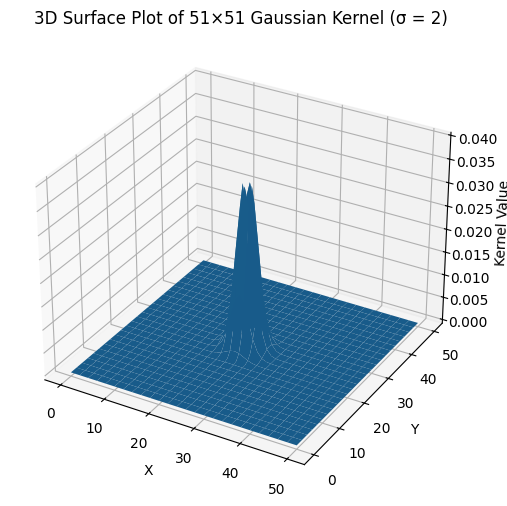

In [3]:
kernel_51x51 = gaussian_kernel(51, 2)

X, Y = np.meshgrid(np.arange(51), np.arange(51))

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, kernel_51x51)
ax.set_title("3D Surface Plot of 51×51 Gaussian Kernel (σ = 2)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Kernel Value")
plt.show()


In [4]:
uploaded = files.upload()
image_name = list(uploaded.keys())[0]

img = cv2.imread(image_name, cv2.IMREAD_GRAYSCALE)


Saving runaway.png to runaway.png


In [5]:
smoothed_manual = cv2.filter2D(img, -1, kernel_5x5)


In [6]:
smoothed_opencv = cv2.GaussianBlur(img, (5,5), 2)


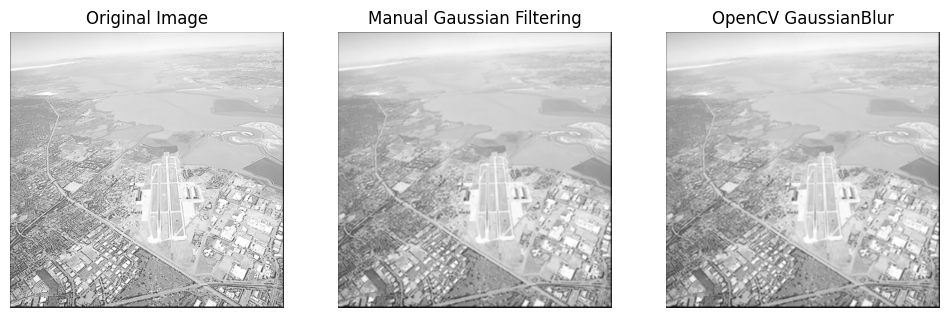

In [7]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(smoothed_manual, cmap='gray')
plt.title("Manual Gaussian Filtering")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(smoothed_opencv, cmap='gray')
plt.title("OpenCV GaussianBlur")
plt.axis('off')

plt.show()
